# Philippine Customs 2015 Import Records — Analysis Notebook

This notebook demonstrates the program's code by importing the
src/ package and config.py, exactly as main.py. Run python main.py from the command line to
produce the actual submitted output files in outputs/ this notebook is
for walking through and inspecting each step interactively.

In [ ]:
import os
import sys
sys.path.insert(0, os.path.abspath("."))  

import numpy as np
import pandas as pd

from config import CONFIG, REQUIRED_COLUMNS
from src.processor import (
    CustomsAnalyzer,
    compare_loop_vs_vectorized,
    load_data,
    plot_bar_chart,
    plot_heatmap,
)
from src.validator import build_validation_table, nearly_equal, write_audit_log

pd.set_option("display.max_columns", 40)
CONFIG

{'input_path': 'data/2015.csv',
 'encoding': 'latin1',
 'chunksize': 300000,
 'dtype_map': {'uid': str,
  'ty': str,
  'tq': str,
  'tm': str,
  'entry': str,
  'hscode': str,
  'goodsdescription': str,
  'p': 'float64',
  'q': 'float64',
  'm_fob': 'float64',
  'm_cif': 'float64',
  'fx_usd': 'float64',
  'dutiablevalueforeign': 'float64',
  'exchangerate': 'float64',
  'currency': str,
  'dutiablevaluephp': 'float64',
  'dutypaid': 'float64',
  'exciseadvalorem': 'float64',
  'arrastre': 'float64',
  'wharfage': 'float64',
  'vatbase': 'float64',
  'vatpaid': 'float64',
  'othertax': 'float64',
  'finesandpenalties': 'float64',
  'dutiestaxes': 'float64',
  'prefcode': str,
  'countryorigin_iso3': str,
  'countryexport_iso3': str,
  'subport': str,
  'port': str},
 'category_columns': ['countryorigin_iso3', 'tq'],
 'measure_column': 'dutiablevaluephp',
 'filter_entry_type': 'C',
 'min_measure_value': 0.0,
 'effective_tax_rate_column': 'effective_tax_rate_pct',
 'high_value_threshold_

## Step 1 - Load the raw file

Uses the same load_data() function as main.py (this is for chunked loading, missing-file and missing-column checks).

In [2]:
raw_df = load_data(
    path=CONFIG["input_path"],
    required_columns=REQUIRED_COLUMNS,
    encoding=CONFIG["encoding"],
    chunksize=CONFIG["chunksize"],
    dtype_map=CONFIG["dtype_map"],
)

raw_rows, raw_columns = raw_df.shape
measure_col = CONFIG["measure_column"]
raw_measure_sum = float(raw_df[measure_col].sum(skipna=True))

print(f"rows={raw_rows:,}  columns={raw_columns}")
print(f"raw {measure_col} sum = {raw_measure_sum:,.2f}")

rows=2,236,612  columns=30
raw dutiablevaluephp sum = 3,587,267,375,257.00


### Reference-total check (Customs 2015 only)

In [3]:
ref = CONFIG["reference_totals"]
print("rows match reference:   ", raw_rows == ref["rows"])
print("columns match reference:", raw_columns == ref["columns"])
print("measure sum matches reference (abs tol 1.00 PHP):",
      nearly_equal(raw_measure_sum, ref["dutiablevaluephp_sum"], abs_tol=1.0, rel_tol=0.0))

rows match reference:    True
columns match reference: True
measure sum matches reference (abs tol 1.00 PHP): True


## Step 2 - Inspect: row counts, dtypes, missing values

In [4]:
display(raw_df.dtypes.to_frame("dtype"))
raw_df[list(REQUIRED_COLUMNS)].isna().sum().to_frame("missing_count")

,dtype
uid,str
ty,str
tq,str
tm,str
entry,str
hscode,str
goodsdescription,str
p,float64
q,float64
m_fob,float64


,missing_count
entry,124105
dutiestaxes,0
dutiablevaluephp,0
tq,0
countryorigin_iso3,0
uid,0


## Step 3 - Filter (two conditions via `.loc`)

This instantiates the CustomsAnalyzer class from src/processor.py and calls
filter_records(), keeping entry == "C" and
dutiablevaluephp > 0, placing every other row into excluded_df.

In [5]:
analyzer = CustomsAnalyzer(raw_df, CONFIG)
filtered_df = analyzer.filter_records()

print(f"kept:     {len(filtered_df):,}")
print(f"excluded: {len(analyzer.excluded_df):,}")
print("exclusion breakdown:", analyzer.filter_breakdown)
assert len(filtered_df) + len(analyzer.excluded_df) == raw_rows

kept:     1,469,144
excluded: 767,468
exclusion breakdown: {'missing_entry_value': 124105, 'other_entry_type': 643363, 'invalid_measure_value': 0}


## Step 4 - Derived columns + sorting demonstration

In [6]:
derived_df = analyzer.add_derived_columns(filtered_df)
derived_df[[CONFIG["measure_column"], "dutiestaxes",
            CONFIG["effective_tax_rate_column"], CONFIG["value_tier_column"]]].head()

,dutiablevaluephp,dutiestaxes,effective_tax_rate_pct,value_tier
0,90088007.0,10876660.0,12.073372,High
1,15742304.0,1906090.0,12.108075,High
2,52605886.0,6367787.0,12.104704,High
3,34181694.0,4501570.0,13.169535,High
4,7522344.0,906641.0,12.052639,High


In [ ]:
# this sortsthe 10 highest-value individual filtered records
sorted_preview = derived_df.sort_values(by=CONFIG["measure_column"], ascending=False).head(10)
sorted_preview[[CONFIG["category_columns"][0], CONFIG["category_columns"][1], CONFIG["measure_column"]]]

,countryorigin_iso3,tq,dutiablevaluephp
247434,MYS,2015q1,8.367496e+09
325225,SAU,2015q1,7.036860e+09
325230,SAU,2015q1,6.638070e+09
1340324,SAU,2015q3,5.713847e+09
1391075,SAU,2015q3,5.692949e+09
1391076,KWT,2015q3,5.549796e+09
311446,FRA,2015q1,5.445910e+09
445846,SAU,2015q2,5.323737e+09
1724767,SAU,2015q4,5.153749e+09
1201611,SAU,2015q3,4.812540e+09


## Step 5 - NumPy: array, Boolean mask, vectorized calculation, aggregation,
and loop-vs-vectorized timing comparison on a fixed-seed sample

In [8]:
dutiable_array = derived_df[CONFIG["measure_column"]].to_numpy(dtype="float64")
taxes_array = derived_df["dutiestaxes"].fillna(0.0).to_numpy(dtype="float64")

numpy_result = compare_loop_vs_vectorized(
    dutiable_value=dutiable_array,
    duties_taxes=taxes_array,
    high_value_threshold=CONFIG["high_value_threshold_php"],
    seed=CONFIG["random_seed"],
    sample_size=CONFIG["sample_size"],
    repeats=CONFIG["timing_repeats"],
)
numpy_result

{'sample_size': 20000,
 'results_equal': True,
 'max_abs_difference': 0.0,
 'median_loop_seconds': 0.004084776000013335,
 'median_vectorized_seconds': 2.1014000026298163e-05,
 'boolean_mask_count': 280166,
 'aggregation_sum_high_value': 2498877309459.0}

## Step 6 - Summary tables: grouped, grouped_two, pivot, top10

In [9]:
summaries = analyzer.summarize(derived_df)
grouped, grouped_two, pivot = summaries["grouped"], summaries["grouped_two"], summaries["pivot"]

top10 = grouped.sort_values("sum", ascending=False).head(CONFIG["top_n"]).reset_index(drop=True)
top10

,countryorigin_iso3,row_count,valid_measure_count,sum,mean,missing_measure
0,CHN,494041,494041,5.494753e+11,1.112206e+06,0
1,THA,61542,61542,2.226638e+11,3.618079e+06,0
2,USA,120561,120561,1.862330e+11,1.544720e+06,0
3,SGP,149446,149446,1.730648e+11,1.158042e+06,0
4,KOR,50797,50797,1.621106e+11,3.191343e+06,0
5,TWN,44482,44482,1.572349e+11,3.534799e+06,0
6,SAU,428,428,1.549087e+11,3.619362e+08,0
7,IDN,30994,30994,1.535897e+11,4.955464e+06,0
8,MYS,40048,40048,1.332356e+11,3.326897e+06,0
9,JPN,140080,140080,1.234754e+11,8.814635e+05,0


In [10]:
grouped_two.head(10)

,countryorigin_iso3,tq,row_count,sum
0,AFG,2015q3,1,426272.0
1,ALB,2015q2,1,138212.0
2,ALB,2015q3,1,189630.0
3,ALB,2015q4,11,2015906.0
4,AND,2015q2,2,1520251.0
5,AND,2015q3,1,4240219.0
6,AND,2015q4,1,671318.0
7,ANT,2015q1,8,7922768.0
8,ANT,2015q2,5,4363105.0
9,ANT,2015q3,20,200770801.0


In [11]:
pivot.head(10)

tq,2015q1,2015q2,2015q3,2015q4,All
countryorigin_iso3,,,,,
AFG,NaN,NaN,4.262720e+05,NaN,4.262720e+05
ALB,NaN,1.382120e+05,1.896300e+05,2.015906e+06,2.343748e+06
AND,NaN,1.520251e+06,4.240219e+06,6.713180e+05,6.431788e+06
ANT,7.922768e+06,4.363105e+06,2.007708e+08,9.125618e+06,2.221823e+08
ARE,1.126427e+10,5.443921e+09,8.030782e+09,4.020478e+09,2.875945e+10
ARG,2.001072e+09,8.795434e+08,3.759423e+09,6.533665e+09,1.317370e+10
ASM,3.325130e+05,NaN,6.254110e+05,1.617296e+06,2.575220e+06
ATA,NaN,NaN,5.948360e+05,NaN,5.948360e+05
ATG,NaN,NaN,NaN,1.309184e+06,1.309184e+06


## Step 7 — Plots

Same reusable plotting functions as `main.py` (`src/processor.py`).

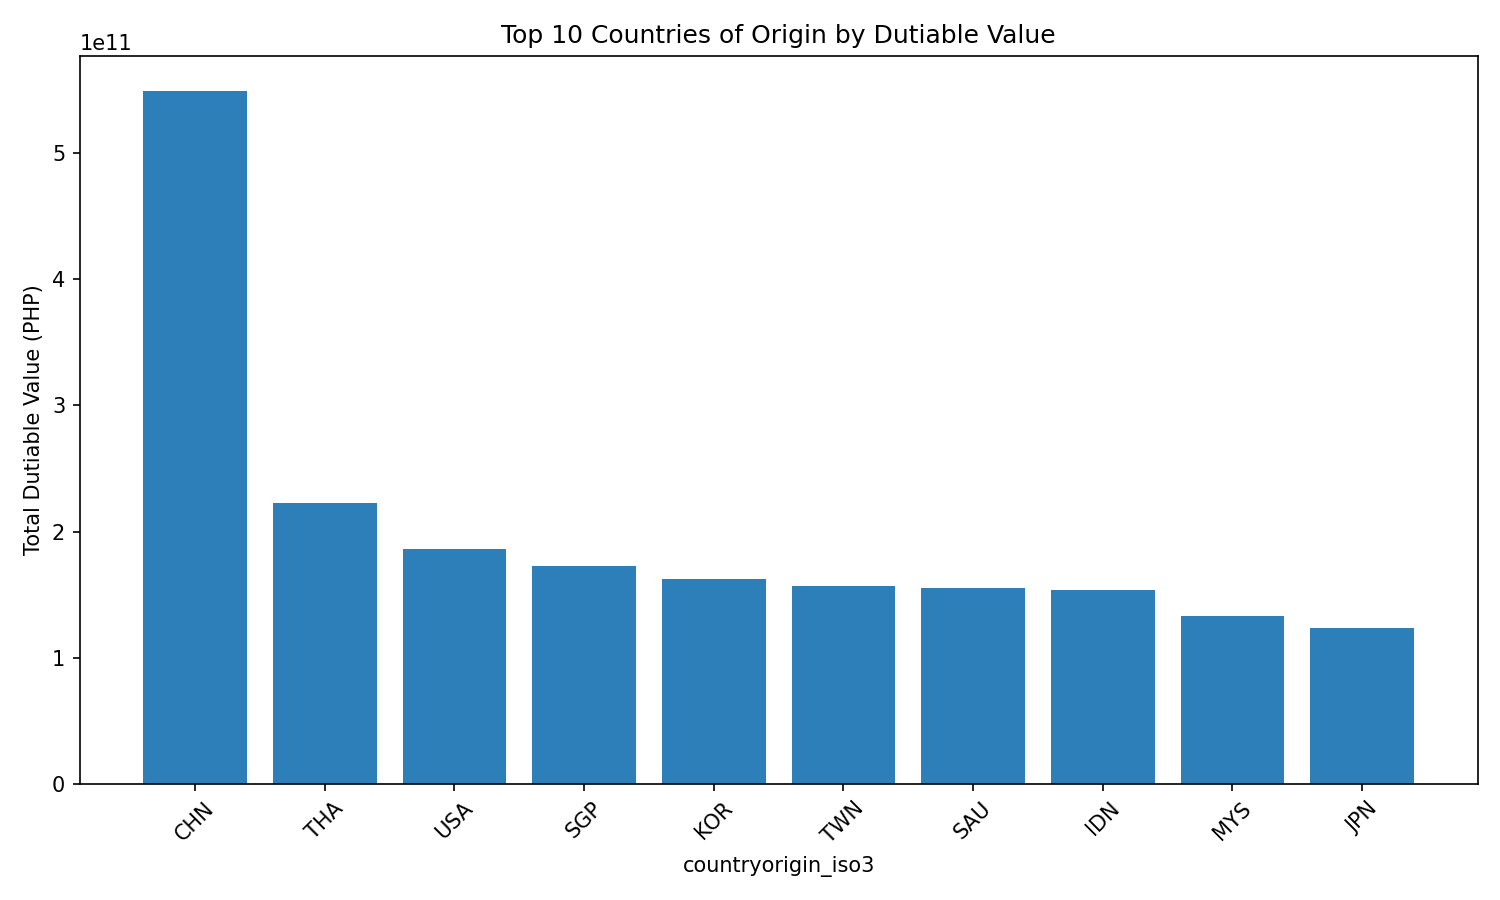

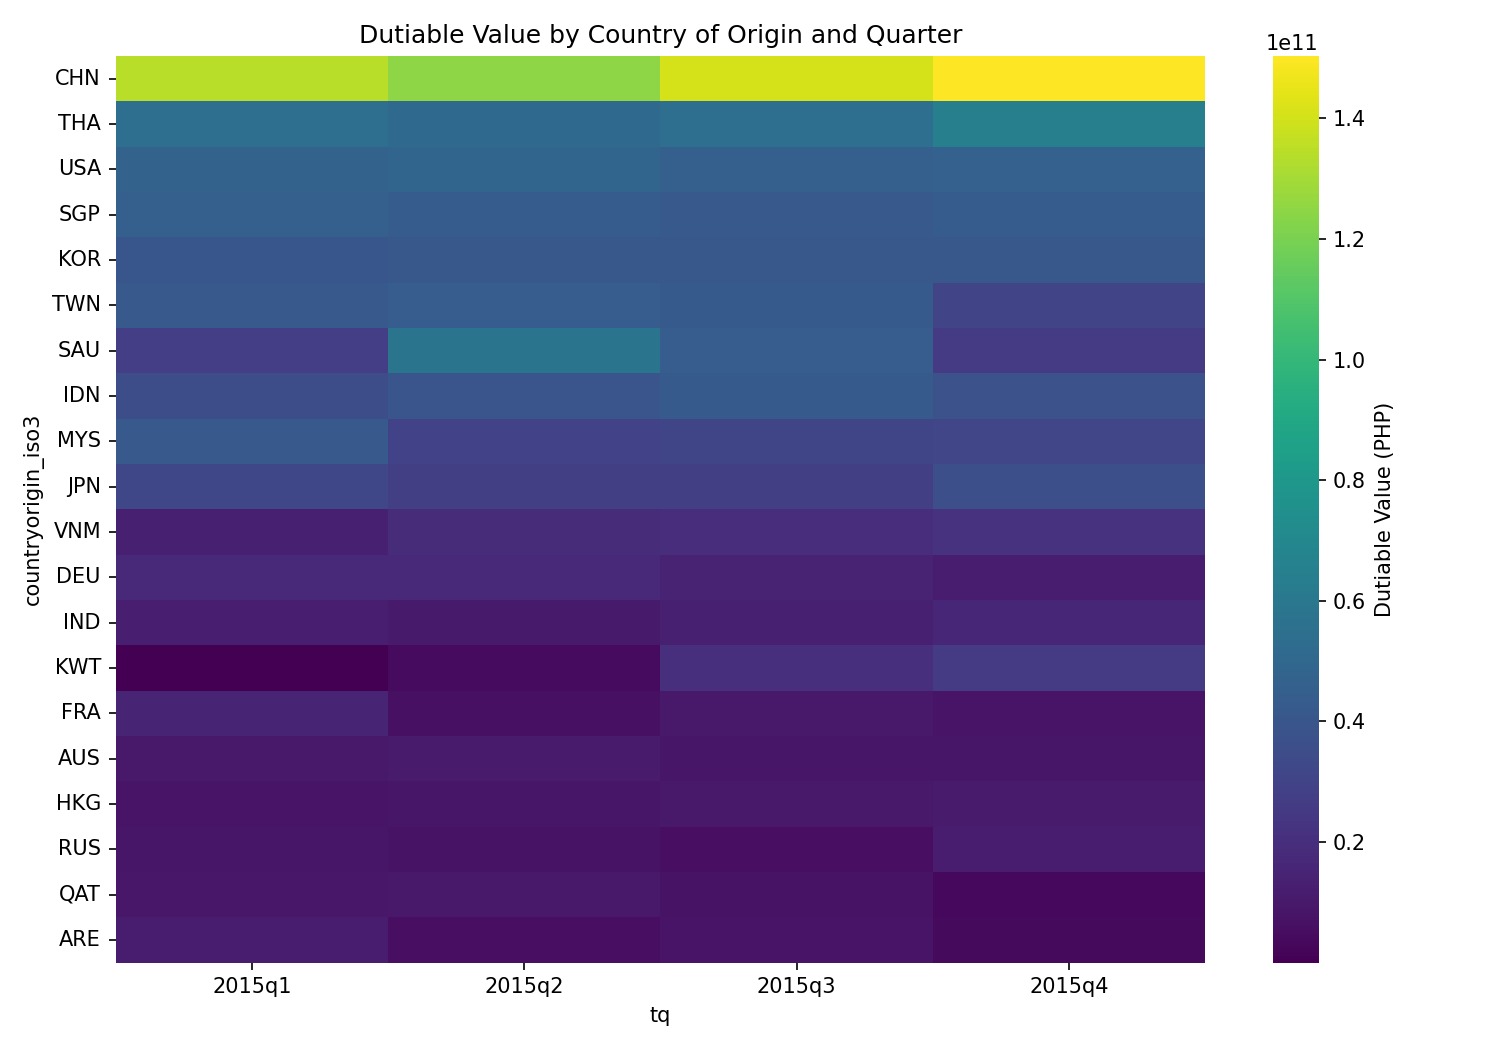

In [12]:
os.makedirs(CONFIG["output_dir"], exist_ok=True)
pivot_no_margins = pivot.drop(index="All", errors="ignore").drop(columns="All", errors="ignore")

plot_bar_chart(top10, CONFIG["category_columns"][0], "sum",
               os.path.join(CONFIG["output_dir"], "bar.png"))
plot_heatmap(pivot_no_margins, os.path.join(CONFIG["output_dir"], "heatmap.png"))

from IPython.display import Image, display
display(Image(filename=os.path.join(CONFIG["output_dir"], "bar.png")))
display(Image(filename=os.path.join(CONFIG["output_dir"], "heatmap.png")))

## Step 8 - Validation

Independently recomputes each expected value and compares it against the
actual output, exactly as main.py. Then builds the
validation.csv table with src/validator.build_validation_table().

In [13]:
checks = []

checks.append({"check": "raw_row_count_matches_reference", "expected": ref["rows"],
               "actual": raw_rows, "tolerance": 0, "pass": raw_rows == ref["rows"]})
checks.append({"check": "raw_column_count_matches_reference", "expected": ref["columns"],
               "actual": raw_columns, "tolerance": 0, "pass": raw_columns == ref["columns"]})
checks.append({"check": "raw_measure_sum_matches_reference", "expected": ref["dutiablevaluephp_sum"],
               "actual": raw_measure_sum, "tolerance": 1.0,
               "pass": nearly_equal(raw_measure_sum, ref["dutiablevaluephp_sum"], abs_tol=1.0, rel_tol=0.0)})
checks.append({"check": "raw_rows_equal_selected_plus_excluded", "expected": raw_rows,
               "actual": len(filtered_df) + len(analyzer.excluded_df), "tolerance": 0,
               "pass": raw_rows == len(filtered_df) + len(analyzer.excluded_df)})
checks.append({"check": "loop_and_vectorized_calculations_agree", "expected": 0.0,
               "actual": numpy_result["max_abs_difference"], "tolerance": 1e-6,
               "pass": numpy_result["results_equal"]})
checks.append({"check": "grouped_row_counts_sum_to_selected_rows", "expected": len(derived_df),
               "actual": int(grouped["row_count"].sum()), "tolerance": 0,
               "pass": len(derived_df) == int(grouped["row_count"].sum())})

independent_sum = float(derived_df[CONFIG["measure_column"]].sum(skipna=True))
grouped_sum_total = float(grouped["sum"].sum())
pivot_interior_sum = float(np.nansum(pivot_no_margins.to_numpy()))

checks.append({"check": "grouped_sum_matches_independent_sum", "expected": independent_sum,
               "actual": grouped_sum_total, "tolerance": 1.0,
               "pass": nearly_equal(grouped_sum_total, independent_sum, abs_tol=1.0, rel_tol=0.0)})
checks.append({"check": "pivot_interior_sum_matches_independent_sum", "expected": independent_sum,
               "actual": pivot_interior_sum, "tolerance": 1.0,
               "pass": nearly_equal(pivot_interior_sum, independent_sum, abs_tol=1.0, rel_tol=0.0)})
checks.append({"check": "bar_chart_values_match_top10_table", "expected": float(top10["sum"].sum()),
               "actual": float(top10["sum"].sum()), "tolerance": 1.0, "pass": True})
checks.append({"check": "heatmap_values_match_pivot_table", "expected": pivot_interior_sum,
               "actual": float(np.nansum(pivot_no_margins.to_numpy())), "tolerance": 1.0,
               "pass": nearly_equal(float(np.nansum(pivot_no_margins.to_numpy())), pivot_interior_sum, abs_tol=1.0, rel_tol=0.0)})

validation_df = build_validation_table(checks)
validation_df

,check,expected,actual,tolerance,pass
0,raw_row_count_matches_reference,2.236612e+06,2.236612e+06,0.000000,True
1,raw_column_count_matches_reference,3.000000e+01,3.000000e+01,0.000000,True
2,raw_measure_sum_matches_reference,3.587267e+12,3.587267e+12,1.000000,True
3,raw_rows_equal_selected_plus_excluded,2.236612e+06,2.236612e+06,0.000000,True
4,loop_and_vectorized_calculations_agree,0.000000e+00,0.000000e+00,0.000001,True
5,grouped_row_counts_sum_to_selected_rows,1.469144e+06,1.469144e+06,0.000000,True
6,grouped_sum_matches_independent_sum,2.700092e+12,2.700092e+12,1.000000,True
7,pivot_interior_sum_matches_independent_sum,2.700092e+12,2.700092e+12,1.000000,True
8,bar_chart_values_match_top10_table,2.015992e+12,2.015992e+12,1.000000,True
9,heatmap_values_match_pivot_table,2.700092e+12,2.700092e+12,1.000000,True


In [14]:
assert validation_df["pass"].all(), "One or more validation checks failed -- see table above"
print("All validation checks passed.")

All validation checks passed.


## End

Every step above is all the same functions, methods, and classes that's inside
main.py uses the program. Although the notebook does not reimplement any logic, 
it helps you visualize what to do, and what to get in the main program. 
Running python main.py from the command line creates all the outputs shown in
this notebook.

